# 01 · Pipeline TDA para mamografía — demostración de extremo a extremo

**mammoviz-tda** · Trabajo de Fin de Grado

Este notebook conecta las cinco etapas del pipeline definidas en `src/`:

1. **Datos** (`data.py`) — carga y partición **por paciente** (evita fuga de datos).
2. **Preprocesado** (`preprocessing.py`) — normalización, ROI, CLAHE, resize.
3. **Topología** (`topology.py`) — homología persistente → vector de características.
4. **Modelos** (`models.py`) — SVM / Random Forest sobre las características topológicas.
5. **Evaluación** (`evaluate.py`) — métricas clínicas y visualización.

> ⚠️ Como CBIS-DDSM aún no está descargado, este notebook usa **datos sintéticos**
> (imágenes con dos "morfologías" distintas) para demostrar que el pipeline funciona
> de principio a fin. Sustituye la sección de datos por la carga real cuando dispongas
> de las imágenes y los CSV de descripción de casos.

## 0. Configuración e imports

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Permite importar el paquete src/ desde el notebook.
ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
sys.path.insert(0, str(ROOT))

SEED = 42
rng = np.random.default_rng(SEED)
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: C:\Users\nickhernd\Desktop\mammoviz-tda


## 1. Datos (sintéticos por ahora)

Generamos dos clases de imágenes en escala de grises de 64×64:

- **Benigno (0):** una masa redondeada y suave (borde bien definido).
- **Maligno (1):** una masa con espículas y textura (bordes irregulares).

Estas diferencias de *forma* son precisamente lo que la homología persistente
está diseñada para capturar. Cuando tengas CBIS-DDSM, reemplaza `make_dataset`
por `load_case_descriptions` + carga de imágenes reales.

In [2]:
# NOTA: metemos ruido fuerte y variabilidad a propósito para que las clases
# se SOLAPEN. Así el problema no es trivial y las métricas resultan realistas
# (evitamos el "1.0 en todo" que sería señal de un problema, no de un buen modelo).
NOISE = 0.16

def synth_benign(size=64):
    """Masa redondeada y suave: un único blob gaussiano de tamaño variable."""
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2 + rng.normal(0, 4), size / 2 + rng.normal(0, 4)
    sigma = size / rng.uniform(4.0, 6.0)               # tamaño variable del blob
    r2 = (xx - cx) ** 2 + (yy - cy) ** 2
    img = rng.uniform(0.6, 1.0) * np.exp(-r2 / (2 * sigma ** 2))
    img += rng.normal(0, NOISE, size=img.shape)         # ruido fuerte
    return np.clip(img, 0, 1)

def synth_malignant(size=64):
    """Masa espiculada: blob + espículas + micro-motas, con señal DÉBIL."""
    img = synth_benign(size)                            # base indistinguible
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2, size / 2
    ang = np.arctan2(yy - cy, xx - cx)
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
    # Espículas suaves (a veces apenas visibles bajo el ruido).
    spicules = (np.cos(ang * rng.integers(8, 14)) > 0.65) & (r < size / 2.5) & (r > size / 6)
    img[spicules] += rng.uniform(0.10, 0.22)
    # Pocas micro-calcificaciones y tenues (crean componentes H0 adicionales).
    for _ in range(rng.integers(2, 7)):
        px, py = rng.integers(0, size, 2)
        img[max(py-1,0):py+1, max(px-1,0):px+1] += rng.uniform(0.2, 0.4)
    return np.clip(img, 0, 1)

def make_dataset(n_per_class=60, size=64):
    """Construye un dataset sintético balanceado y su vector de etiquetas."""
    imgs, labels = [], []
    for _ in range(n_per_class):
        imgs.append(synth_benign(size));    labels.append(0)
        imgs.append(synth_malignant(size)); labels.append(1)
    return np.array(imgs), np.array(labels)

X_img, y = make_dataset()
print("Imágenes:", X_img.shape, "· Etiquetas:", np.bincount(y))

Imágenes: (120, 64, 64) · Etiquetas: [60 60]


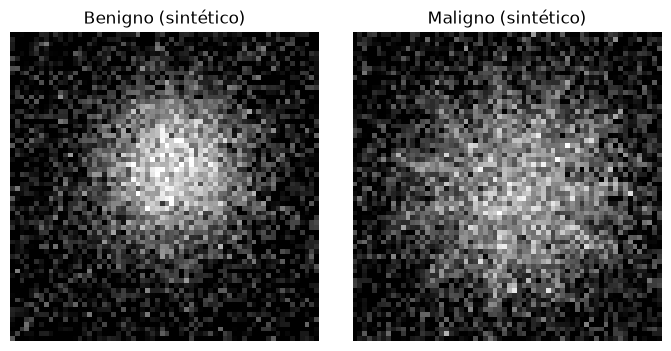

In [3]:
# Visualizamos un ejemplo de cada clase.
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(X_img[0], cmap="gray"); axes[0].set_title("Benigno (sintético)")
axes[1].imshow(X_img[1], cmap="gray"); axes[1].set_title("Maligno (sintético)")
for a in axes: a.axis("off")
plt.tight_layout(); plt.show()

### Partición por paciente

Aquí cada imagen sintética se trata como un "paciente" independiente, así que
una partición estratificada normal es suficiente para la demo. **Con datos reales**
usarías `src.data.split_by_patient`, que garantiza que ninguna imagen de un mismo
paciente caiga en dos particiones (la clave para evitar la fuga de datos).

In [4]:
from sklearn.model_selection import train_test_split

X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_img, y, test_size=0.25, stratify=y, random_state=SEED
)
print("Train:", len(y_train), "· Test:", len(y_test))

Train: 90 · Test: 30


## 2. Preprocesado

Nuestras imágenes sintéticas ya están en escala de grises y normalizadas, así que
aquí solo mostramos el punto de enganche. Con datos reales llamarías a
`src.preprocessing.preprocess(imagen, mascara)` para hacer gris → ROI → CLAHE → resize.

In [5]:
# Con datos reales:
# from src.preprocessing import preprocess
# img_pp = preprocess(imagen_cruda, mascara_roi, size=(64, 64), use_clahe=True)
# En la demo usamos las imágenes tal cual.
X_train_pp, X_test_pp = X_train_img, X_test_img

## 3. Extracción de características topológicas

Intentamos usar `src.topology` (giotto-tda). Si giotto-tda no está instalado,
usamos un **descriptor topológico de respaldo basado en la curva de Betti-0**
calculada con `scipy` (cuenta cómo evoluciona el número de componentes conexas
al ir bajando el umbral de intensidad). Ambas vías producen un vector de tamaño
fijo por imagen.

In [6]:
def _betti0_features(img, n_levels=24):
    """Respaldo sin giotto-tda: curva de Betti-0 por sublevel sets.

    Para una serie de umbrales crecientes, binarizamos la imagen y contamos el
    número de componentes conexas con scipy. La secuencia resultante resume cómo
    nacen y se fusionan las regiones -> un descriptor topológico simple.
    """
    from scipy import ndimage
    levels = np.linspace(img.min(), img.max(), n_levels)
    betti0 = [ndimage.label(img >= t)[1] for t in levels]
    return np.asarray(betti0, dtype=np.float32)

# Probamos giotto-tda con una extracción real sobre una imagen diminuta.
# (Importar src.topology SIEMPRE funciona; lo que puede fallar es ejecutar la
#  homología persistente si giotto-tda no está instalado.)
try:
    from src.topology import extract_features
    _ = extract_features(np.zeros((8, 8), np.float32), method="image", n_bins=4)
    def tda_features(img):
        return extract_features(img.astype(np.float32), method="image", n_bins=12)
    BACKEND = "giotto-tda (persistence image)"
except Exception:
    tda_features = _betti0_features
    BACKEND = "respaldo scipy (curva de Betti-0)"

print("Backend topológico:", BACKEND)

# Extraemos características para train y test.
F_train = np.array([tda_features(im) for im in X_train_pp])
F_test  = np.array([tda_features(im) for im in X_test_pp])
print("Vector de características:", F_train.shape[1], "dimensiones por imagen")

Backend topológico: respaldo scipy (curva de Betti-0)
Vector de características: 24 dimensiones por imagen


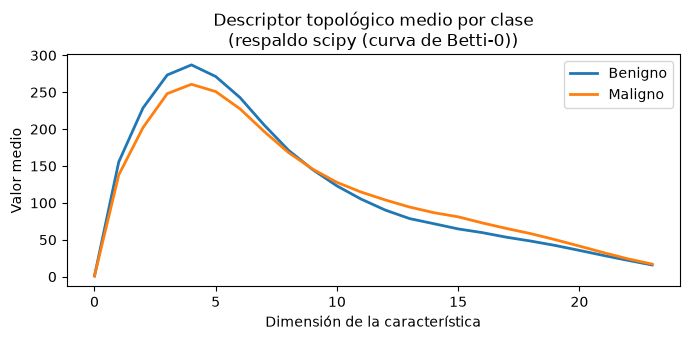

In [7]:
# ¿Separan las características topológicas las dos clases? Vista rápida de la
# característica media por clase.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(F_train[y_train == 0].mean(0), label="Benigno", lw=2)
ax.plot(F_train[y_train == 1].mean(0), label="Maligno", lw=2)
ax.set_title(f"Descriptor topológico medio por clase\n({BACKEND})")
ax.set_xlabel("Dimensión de la característica"); ax.set_ylabel("Valor medio")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Clasificación sobre las características topológicas

Entrenamos los dos clasificadores clásicos definidos en `src.models`
(SVM con RBF y Random Forest). Aprenden **solo** a partir del vector topológico,
sin ver los píxeles directamente.

In [8]:
from src.models import build_svm, build_random_forest

modelos = {"SVM (RBF)": build_svm(), "Random Forest": build_random_forest()}
for m in modelos.values():
    m.fit(F_train, y_train)
print("Modelos entrenados:", list(modelos))

C:\Users\nickhernd\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Modelos entrenados: ['SVM (RBF)', 'Random Forest']


## 5. Evaluación con métricas clínicas

Usamos `src.evaluate.clinical_metrics`, que además de la exactitud reporta
**sensibilidad** y **especificidad** — lo relevante en cribado, donde un falso
negativo (no detectar un maligno) es el error más costoso.

In [9]:
from src.evaluate import clinical_metrics, plot_confusion
import pandas as pd

filas = []
for nombre, m in modelos.items():
    y_pred = m.predict(F_test)
    y_score = m.predict_proba(F_test)[:, 1]   # prob. de la clase maligna
    met = clinical_metrics(y_test, y_pred, y_score)
    met["modelo"] = nombre
    filas.append(met)

tabla = pd.DataFrame(filas).set_index("modelo").round(3)
tabla

,accuracy,sensibilidad_recall,especificidad,precision,f1,auc
modelo,,,,,,
SVM (RBF),0.7,0.533,0.867,0.80,0.640,0.742
Random Forest,0.7,0.600,0.800,0.75,0.667,0.782


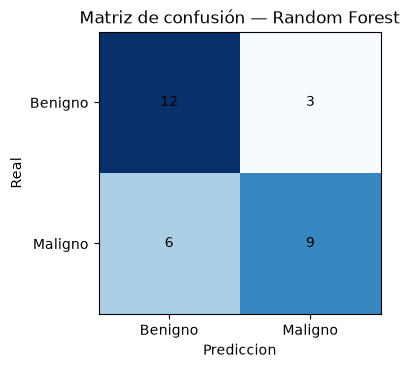

Mejor modelo por F1: Random Forest


In [10]:
# Matriz de confusión del mejor modelo (por F1).
mejor = tabla["f1"].idxmax()
y_pred = modelos[mejor].predict(F_test)
ax = plot_confusion(y_test, y_pred)
ax.set_title(f"Matriz de confusión — {mejor}")
plt.tight_layout(); plt.show()
print("Mejor modelo por F1:", mejor)

## 6. Visualización del diagrama de persistencia (si hay giotto-tda)

El diagrama de persistencia es la representación interpretable central del TDA:
cada punto es una característica topológica; cuanto más lejos de la diagonal,
más persiste (más relevante). Esta celda solo se ejecuta si giotto-tda está disponible.

In [11]:
try:
    from src.topology import persistence_diagram
    from src.evaluate import plot_persistence_diagram
    diag_b = persistence_diagram(X_train_pp[np.where(y_train == 0)[0][0]].astype(np.float32))
    diag_m = persistence_diagram(X_train_pp[np.where(y_train == 1)[0][0]].astype(np.float32))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    plot_persistence_diagram(diag_b, ax=axes[0]); axes[0].set_title("Benigno")
    plot_persistence_diagram(diag_m, ax=axes[1]); axes[1].set_title("Maligno")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("Diagrama de persistencia no disponible (instala giotto-tda para verlo).")
    print("Detalle:", e)

Diagrama de persistencia no disponible (instala giotto-tda para verlo).
Detalle: giotto-tda es necesario. Instala con: pip install giotto-tda


## 7. Siguientes pasos con datos reales

Para pasar de la demo a los experimentos del TFG:

1. **Descargar CBIS-DDSM** (imágenes + CSV de descripción de casos) → `data/`.
2. Sustituir la **sección 1** por:
   ```python
   from src.data import load_case_descriptions, split_by_patient
   casos = load_case_descriptions("data/csv")
   parts = split_by_patient(casos, patient_col="patient_id", label_col="label")
   ```
3. Cargar cada imagen/máscara y pasarla por `src.preprocessing.preprocess`.
4. Instalar **giotto-tda** para usar imágenes de persistencia reales.
5. Añadir la **CNN de referencia** (`src.models.build_cnn`) y el experimento de **fusión**.
6. Volcar la tabla de resultados en el Capítulo 7 de la memoria (`tfg/`).